<a href="https://colab.research.google.com/github/Saibhossain/Agentic-framework/blob/main/Parallel_workflow_LangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
!pip install langchain
!pip install langgraph
!pip install langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.9 MB/s eta 0:00:00


# simple parallel workflow

In [70]:
from langgraph import graph
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: int
    bpd: int
    boundry_percent: float
    summary: str

### functions

run the function first -- observe the error

In [5]:
def calculate_sr(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    balls = state["balls"]
    sr = (runs / balls)*100

    state["sr"] = sr

    return state

def calculate_bpd(state: BatsmanState) -> BatsmanState:

    bpd = state['balls']/(state['fours'] + state['sixes'])

    state["bpd"] = bpd

    return state

def calculate_boundry_percent(state: BatsmanState) -> BatsmanState:
    total_boundries = ((state['fours']*4) + (state['sixes']*6))*100
    state["boundry_percent"] = total_boundries

    return state

def summary(state: BatsmanState) -> BatsmanState:
    summary = f"""
    strike rate: {state['sr']}\n
    Ball par boundary : {state['bpd']}\n
    boundary percent: {state['boundry_percent']}
    """
    state["summary"] = summary

    return state

after observing error run this function and the return back and run the invoke code

In [71]:
def calculate_sr(state: BatsmanState) -> BatsmanState:
    runs = state["runs"]
    balls = state["balls"]
    sr = (runs / balls)*100

    return {'sr' : sr }




def calculate_bpd(state: BatsmanState) -> BatsmanState:

    bpd = state['balls']/(state['fours'] + state['sixes'])

    return {'bpd':bpd}



def calculate_boundry_percent(state: BatsmanState) -> BatsmanState:
    boundry_percent = ((state['fours']*4) + (state['sixes']*6))*100

    return {'boundry_percent':boundry_percent}



def summary(state: BatsmanState) -> BatsmanState:
    summary = f"""
    strike rate: {state['sr']}\n
    Ball par boundary : {state['bpd']}\n
    boundary percent: {state['boundry_percent']}
    """
    return {'summary':summary}

## orchester

In [72]:
graph = StateGraph(BatsmanState)

In [73]:
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_bpd',calculate_bpd)
graph.add_node('calculate_boundry_percent',calculate_boundry_percent)
graph.add_node('summary',summary)


graph.add_edge(START,  'calculate_sr')
graph.add_edge(START,  'calculate_bpd')
graph.add_edge(START,  'calculate_boundry_percent')


graph.add_edge('calculate_sr', 'summary')
graph.add_edge('calculate_bpd', 'summary')
graph.add_edge('calculate_boundry_percent', 'summary')
graph.add_edge('summary', END)


workflow = graph.compile()

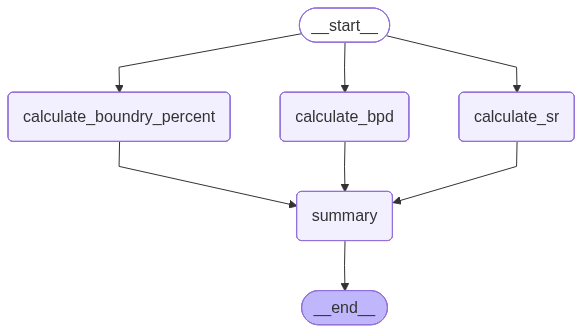

In [63]:
workflow

In [56]:
initial_state = {
    'runs':100,
    'balls':50,
    'fours':6,
    'sixes':4
}
workflow.invoke(initial_state)

TypeError: BatsmanState() takes no keyword arguments

In [75]:
initial_state = {
    'runs':100,
    'balls':50,
    'fours':6,
    'sixes': 4
}
workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpd': 5.0,
 'boundry_percent': 4800,
 'summary': '\n    strike rate: 200.0\n\n    Ball par boundary : 5.0\n\n    boundary percent: 4800\n    '}

# LLM with prompt chain  v2

In [ ]:
from langgraph import graph
import os
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from google.colab import userdata
userdata.get('google_api')
load_dotenv()


# Get the API key from Colab's user data and set it as an environment variable
os.environ['GOOGLE_API_KEY'] = userdata.get('google_api')

model = init_chat_model("google_genai:gemini-2.5-flash-lite")

class Blogstate(TypedDict):

    title: str
    outline: str
    content: str

In [ ]:
def create_outline(state: Blogstate) -> Blogstate:

    title = state["title"]

    prompt = f"Create a detailed outline for a blog post on this topic {title}"
    outline = model.invoke(prompt).content
    state["outline"] = outline

    return state

In [ ]:
def create_blog_content(state: Blogstate) -> Blogstate:

    title = state["title"]
    outline = state["outline"]
    prompt = f"Write a detailed blog post on this topic {title} using this outline {outline}"
    content = model.invoke(prompt).content
    state["content"] = content

    return state

In [ ]:
graph = StateGraph(Blogstate)


graph.add_node('create_outline',create_outline)
graph.add_node('create_blog_content',create_blog_content)

graph.add_edge(START,  'create_outline')
graph.add_edge('create_outline', 'create_blog_content')
graph.add_edge('create_blog_content', END)

workflow = graph.compile()


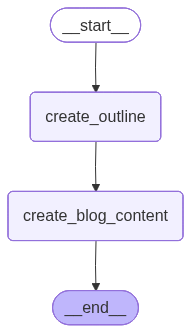

In [ ]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [ ]:
initial_states = {'title':'rise of Ai job in bangladesh'}

final_state = workflow.invoke(initial_states)

print(final_state)

{'title': 'rise of Ai job in bangladesh', 'outline': '## Blog Post Outline: The Rise of AI Jobs in Bangladesh\n\n**Title Options:**\n\n* **The Dawn of AI: Emerging Job Opportunities in Bangladesh**\n* **Bangladesh\'s AI Revolution: Unlocking a New Era of Employment**\n* **From Traditional to Tech: How AI is Reshaping the Job Market in Bangladesh**\n* **Future-Proofing Your Career: The Growing Demand for AI Skills in Bangladesh**\n\n**I. Introduction**\n\n*   **Hook:** Start with a compelling statistic or a relatable anecdote about the rapid technological advancements and their impact on the global job market.\n*   **Introduce the Topic:** Briefly define Artificial Intelligence (AI) and its growing significance.\n*   **Thesis Statement:** State that Bangladesh, while traditionally known for certain industries, is experiencing a significant rise in AI-driven job opportunities, creating a new landscape for its workforce.\n*   **Briefly outline what the blog post will cover:** (e.g., curre

In [ ]:
final_state['outline']

'## Blog Post Outline: The Rise of AI Jobs in Bangladesh\n\n**Title Options:**\n\n* **The Dawn of AI: Emerging Job Opportunities in Bangladesh**\n* **Bangladesh\'s AI Revolution: Unlocking a New Era of Employment**\n* **From Traditional to Tech: How AI is Reshaping the Job Market in Bangladesh**\n* **Future-Proofing Your Career: The Growing Demand for AI Skills in Bangladesh**\n\n**I. Introduction**\n\n*   **Hook:** Start with a compelling statistic or a relatable anecdote about the rapid technological advancements and their impact on the global job market.\n*   **Introduce the Topic:** Briefly define Artificial Intelligence (AI) and its growing significance.\n*   **Thesis Statement:** State that Bangladesh, while traditionally known for certain industries, is experiencing a significant rise in AI-driven job opportunities, creating a new landscape for its workforce.\n*   **Briefly outline what the blog post will cover:** (e.g., current AI landscape in Bangladesh, key AI job roles, requ